# Qual é o impacto da escolaridade sobre o salário no Brasil? 

## Pacotes e Arquivo

In [1]:
# Instalar Pacotes
!pip install linearmodels

In [2]:
# Carregar Pacotes
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from linearmodels.panel import PanelOLS

In [3]:
# Carregar arquivo
df = pd.read_excel("tabela5438_arrumada.xlsx")

In [4]:
# Filtra só as linhas relevantes (BR e UF)
df = df[df["tipo_uf"].isin(["BR", "UF"])]

In [5]:
# Converte o wide em long
df_long = df.melt(
    id_vars=["tipo_uf", "uf"],
    var_name="periodo_nivel",
    value_name="rendimento"
)


In [6]:
# Separa "periodo" (ex: "1º trimestre 2012") do "nivel_instrucao"
df_long[["periodo", "nivel_instrucao"]] = df_long["periodo_nivel"].str.split("_", n=1, expand=True)


In [7]:
# A partir daqui você pode extrair ano e trimestre com regex ou replace:
df_long["ano"] = df_long["periodo"].str.extract(r"(\d{4})").astype(int)
df_long["trimestre"] = df_long["periodo"].str.extract(r"(\d)").astype(int)

In [8]:
df_long.head(10)

,tipo_uf,uf,periodo_nivel,rendimento,periodo,nivel_instrucao,ano,trimestre
0,BR,Brasil,1º trimestre 2012_Total,2953.0,1º trimestre 2012,Total,2012,1
1,UF,Rondônia,1º trimestre 2012_Total,2556.0,1º trimestre 2012,Total,2012,1
2,UF,Acre,1º trimestre 2012_Total,2735.0,1º trimestre 2012,Total,2012,1
3,UF,Amazonas,1º trimestre 2012_Total,2713.0,1º trimestre 2012,Total,2012,1
4,UF,Roraima,1º trimestre 2012_Total,3022.0,1º trimestre 2012,Total,2012,1
5,UF,Pará,1º trimestre 2012_Total,2103.0,1º trimestre 2012,Total,2012,1
6,UF,Amapá,1º trimestre 2012_Total,2575.0,1º trimestre 2012,Total,2012,1
7,UF,Tocantins,1º trimestre 2012_Total,2452.0,1º trimestre 2012,Total,2012,1
8,UF,Maranhão,1º trimestre 2012_Total,1608.0,1º trimestre 2012,Total,2012,1
9,UF,Piauí,1º trimestre 2012_Total,1679.0,1º trimestre 2012,Total,2012,1


In [9]:
df_long.tail(10)

,tipo_uf,uf,periodo_nivel,rendimento,periodo,nivel_instrucao,ano,trimestre
11834,UF,Espírito Santo,3º trimestre 2025_Não determinado,-,3º trimestre 2025,Não determinado,2025,3
11835,UF,Rio de Janeiro,3º trimestre 2025_Não determinado,-,3º trimestre 2025,Não determinado,2025,3
11836,UF,São Paulo,3º trimestre 2025_Não determinado,-,3º trimestre 2025,Não determinado,2025,3
11837,UF,Paraná,3º trimestre 2025_Não determinado,-,3º trimestre 2025,Não determinado,2025,3
11838,UF,Santa Catarina,3º trimestre 2025_Não determinado,-,3º trimestre 2025,Não determinado,2025,3
11839,UF,Rio Grande do Sul,3º trimestre 2025_Não determinado,-,3º trimestre 2025,Não determinado,2025,3
11840,UF,Mato Grosso do Sul,3º trimestre 2025_Não determinado,-,3º trimestre 2025,Não determinado,2025,3
11841,UF,Mato Grosso,3º trimestre 2025_Não determinado,-,3º trimestre 2025,Não determinado,2025,3
11842,UF,Goiás,3º trimestre 2025_Não determinado,-,3º trimestre 2025,Não determinado,2025,3
11843,UF,Distrito Federal,3º trimestre 2025_Não determinado,-,3º trimestre 2025,Não determinado,2025,3


## Criar a base econométrica (painel UF × trimestre × educação)

In [10]:
# Filtrar só UFs
df = df_long[df_long["tipo_uf"] == "UF"].copy()

df.head()

,tipo_uf,uf,periodo_nivel,rendimento,periodo,nivel_instrucao,ano,trimestre
1,UF,Rondônia,1º trimestre 2012_Total,2556.0,1º trimestre 2012,Total,2012,1
2,UF,Acre,1º trimestre 2012_Total,2735.0,1º trimestre 2012,Total,2012,1
3,UF,Amazonas,1º trimestre 2012_Total,2713.0,1º trimestre 2012,Total,2012,1
4,UF,Roraima,1º trimestre 2012_Total,3022.0,1º trimestre 2012,Total,2012,1
5,UF,Pará,1º trimestre 2012_Total,2103.0,1º trimestre 2012,Total,2012,1


In [11]:
# Excluir “Total” dos níveis de instrução
df = df[df["nivel_instrucao"] != "Total"].copy()

valid_levels = [
    "Sem instrução e menos de 1 ano de estudo",
    "Ensino fundamental incompleto ou equivalente",
    "Ensino fundamental completo ou equivalente",
    "Ensino médio incompleto ou equivalente",
    "Ensino médio completo ou equivalente",
    "Ensino superior incompleto ou equivalente",
    "Ensino superior completo ou equivalente",
]

df = df[df["nivel_instrucao"].isin(valid_levels)].copy()

In [12]:
# Conferir
df["nivel_instrucao"].value_counts()

nivel_instrucao
Sem instrução e menos de 1 ano de estudo        1269
Ensino fundamental incompleto ou equivalente    1269
Ensino fundamental completo ou equivalente      1269
Ensino médio incompleto ou equivalente          1269
Ensino médio completo ou equivalente            1269
Ensino superior incompleto ou equivalente       1269
Ensino superior completo ou equivalente         1269
Name: count, dtype: int64

In [13]:
# Criar a Variável anos_estudo
mapping_anos = {
    "Sem instrução e menos de 1 ano de estudo": 0.5,
    "Ensino fundamental incompleto ou equivalente": 4,
    "Ensino fundamental completo ou equivalente": 9,
    "Ensino médio incompleto ou equivalente": 10.5,
    "Ensino médio completo ou equivalente": 12,
    "Ensino superior incompleto ou equivalente": 15,
    "Ensino superior completo ou equivalente": 16,
}

df["anos_estudo"] = df["nivel_instrucao"].map(mapping_anos)

In [14]:
# Conferir
df[["nivel_instrucao", "anos_estudo"]].drop_duplicates().sort_values("anos_estudo")

,nivel_instrucao,anos_estudo
29,Sem instrução e menos de 1 ano de estudo,0.5
57,Ensino fundamental incompleto ou equivalente,4.0
85,Ensino fundamental completo ou equivalente,9.0
113,Ensino médio incompleto ou equivalente,10.5
141,Ensino médio completo ou equivalente,12.0
169,Ensino superior incompleto ou equivalente,15.0
197,Ensino superior completo ou equivalente,16.0


In [15]:
# converter rendimento para float
df["rendimento"] = pd.to_numeric(df["rendimento"], errors="coerce")

In [16]:
# filtrar somente rendimentos positivos e não nulos
df = df[df["rendimento"].notna() & (df["rendimento"] > 0)].copy()

In [17]:
# criar o log do rendimento
df["ln_rendimento"] = np.log(df["rendimento"])

In [18]:
# conferir
df[["uf", "ano", "trimestre", "nivel_instrucao", 
    "rendimento", "ln_rendimento", "anos_estudo"]].head(10)

,uf,ano,trimestre,nivel_instrucao,rendimento,ln_rendimento,anos_estudo
29,Rondônia,2012,1,Sem instrução e menos de 1 ano de estudo,1668.0,7.419381,0.5
30,Acre,2012,1,Sem instrução e menos de 1 ano de estudo,1220.0,7.106606,0.5
31,Amazonas,2012,1,Sem instrução e menos de 1 ano de estudo,2237.0,7.712891,0.5
32,Roraima,2012,1,Sem instrução e menos de 1 ano de estudo,2060.0,7.630461,0.5
33,Pará,2012,1,Sem instrução e menos de 1 ano de estudo,1087.0,6.991177,0.5
34,Amapá,2012,1,Sem instrução e menos de 1 ano de estudo,1071.0,6.976348,0.5
35,Tocantins,2012,1,Sem instrução e menos de 1 ano de estudo,1123.0,7.023759,0.5
36,Maranhão,2012,1,Sem instrução e menos de 1 ano de estudo,674.0,6.513230,0.5
37,Piauí,2012,1,Sem instrução e menos de 1 ano de estudo,617.0,6.424869,0.5
38,Ceará,2012,1,Sem instrução e menos de 1 ano de estudo,855.0,6.751101,0.5


## Descrição da amostra

In [19]:
# 1. Tamanho da amostra
n_obs = len(df)

# 2. Período de anos e trimestres
ano_min = df["ano"].min()
ano_max = df["ano"].max()
trimestres = sorted(df["trimestre"].unique())

# 3. Número de UFs e lista
n_ufs = df["uf"].nunique()
lista_ufs = sorted(df["uf"].unique())

# 4. (Opcional) número de observações por UF
obs_por_uf = df["uf"].value_counts().sort_index()

print("=== Descrição da Amostra ===")
print(f"N observações: {n_obs}")
print(f"Período: {ano_min} a {ano_max}")
print(f"Trimestres utilizados: {trimestres}")
print(f"Número de UFs: {n_ufs}")
print(f"UFs na base: {lista_ufs}")
print("\nObservações por UF:")
print(obs_por_uf)

=== Descrição da Amostra ===
N observações: 8883
Período: 2012 a 2025
Trimestres utilizados: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Número de UFs: 27
UFs na base: ['Acre', 'Alagoas', 'Amapá', 'Amazonas', 'Bahia', 'Ceará', 'Distrito Federal', 'Espírito Santo', 'Goiás', 'Maranhão', 'Mato Grosso', 'Mato Grosso do Sul', 'Minas Gerais', 'Paraná', 'Paraíba', 'Pará', 'Pernambuco', 'Piauí', 'Rio Grande do Norte', 'Rio Grande do Sul', 'Rio de Janeiro', 'Rondônia', 'Roraima', 'Santa Catarina', 'Sergipe', 'São Paulo', 'Tocantins']

Observações por UF:
uf
Acre                   329
Alagoas                329
Amapá                  329
Amazonas               329
Bahia                  329
Ceará                  329
Distrito Federal       329
Espírito Santo         329
Goiás                  329
Maranhão               329
Mato Grosso            329
Mato Grosso do Sul     329
Minas Gerais           329
Paraná                 329
Paraíba                329
Pará                   329
Pern

## Estatísticas descritivas principais

In [20]:
vars_desc = ["rendimento", "ln_rendimento", "anos_estudo"]

desc = (
    df[vars_desc]
    .describe()       # count, mean, std, min, 25%, 50%, 75%, max
    .T                # transpor: linhas = variáveis
)

# arredondar para ficar bonito
desc_rounded = desc.round(2)

print(desc_rounded)

                count     mean      std     min      25%      50%      75%  \
rendimento     8883.0  2574.45  1623.35  485.00  1556.00  2107.00  2784.00   
ln_rendimento  8883.0     7.70     0.52    6.18     7.35     7.65     7.93   
anos_estudo    8883.0     9.57     5.23    0.50     4.00    10.50    15.00   

                    max  
rendimento     12910.00  
ln_rendimento      9.47  
anos_estudo       16.00  


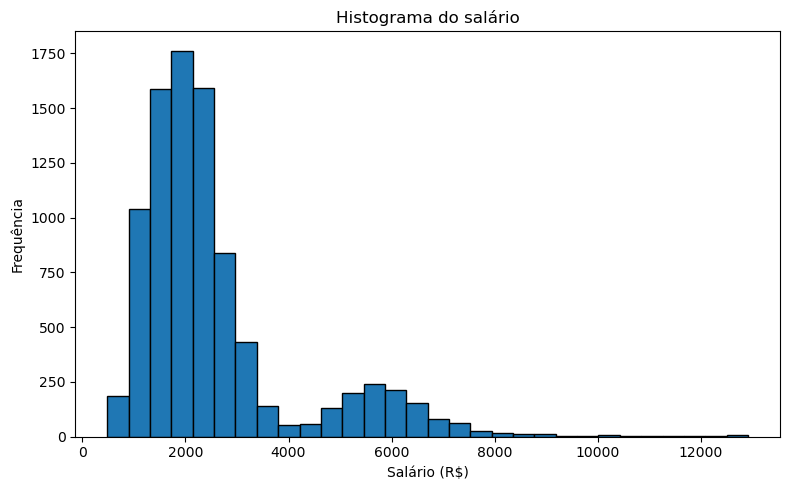

In [21]:
# Histograma do salário
plt.figure(figsize=(8, 5))
plt.hist(df["rendimento"], bins=30, edgecolor="black")
plt.title("Histograma do salário")
plt.xlabel("Salário (R$)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

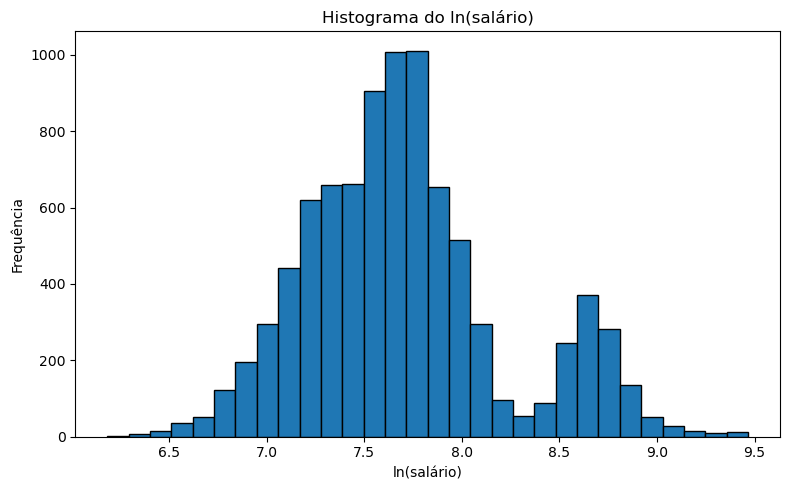

In [22]:
# Histograma do ln(salário)
plt.figure(figsize=(8, 5))
plt.hist(df["ln_rendimento"], bins=30, edgecolor="black")
plt.title("Histograma do ln(salário)")
plt.xlabel("ln(salário)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

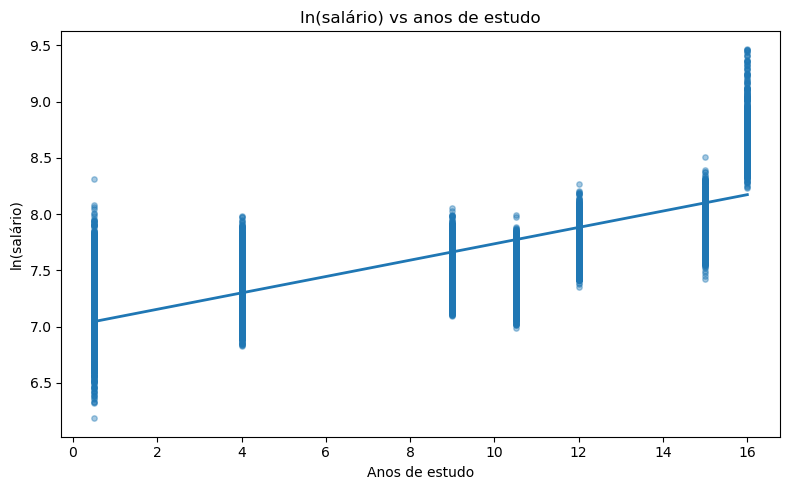

In [23]:
# Scatter plot com linha de regressão simples
X = sm.add_constant(df["anos_estudo"])
y = df["ln_rendimento"]
model = sm.OLS(y, X).fit()

# Predição da reta
anos_grid = np.linspace(df["anos_estudo"].min(),
                        df["anos_estudo"].max(), 100)
X_grid = sm.add_constant(anos_grid)
y_pred = model.predict(X_grid)

plt.figure(figsize=(8, 5))
plt.scatter(df["anos_estudo"], df["ln_rendimento"],
            alpha=0.4, s=15)
plt.plot(anos_grid, y_pred, linewidth=2)
plt.title("ln(salário) vs anos de estudo")
plt.xlabel("Anos de estudo")
plt.ylabel("ln(salário)")
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

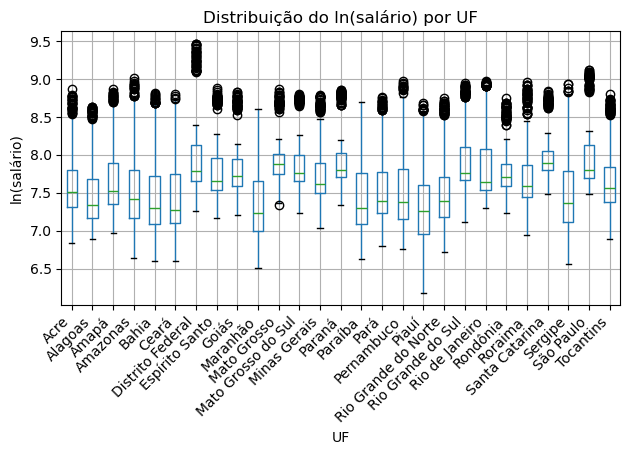

In [24]:
# ordenar UFs pela mediana do ln(salário)
ordem_ufs = (
    df.groupby("uf")["ln_rendimento"]
      .median()
      .sort_values()
      .index
)

df_sorted = df.set_index("uf").loc[ordem_ufs].reset_index()

plt.figure(figsize=(14, 6))  # aumenta largura e altura do gráfico
ax = df_sorted.boxplot(column="ln_rendimento", by="uf")

# Título e eixos
ax.set_title("Distribuição do ln(salário) por UF")
plt.suptitle("")  # remove título automático do pandas
ax.set_xlabel("UF")
ax.set_ylabel("ln(salário)")

# Ajustar os rótulos do eixo X
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,      # rotaciona
    ha="right",       # alinha à direita para não colidir
    fontsize=10       # aumenta fonte
)

plt.subplots_adjust(bottom=0.25)  # aumenta a margem embaixo
plt.tight_layout()
plt.show()

## Modelo 1: Regressão Minceriana Básica

ln(salario)=β0 + β1anos_estudo + u

In [25]:
# regressão minceriana básica
reg1 = smf.ols("ln_rendimento ~ anos_estudo", data=df).fit(cov_type="HC3")
print(reg1.summary())

                            OLS Regression Results                            
Dep. Variable:          ln_rendimento   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     8149.
Date:                Tue, 25 Nov 2025   Prob (F-statistic):               0.00
Time:                        00:19:40   Log-Likelihood:                -3355.8
No. Observations:                8883   AIC:                             6716.
Df Residuals:                    8881   BIC:                             6730.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       7.0079      0.008    857.611      

In [28]:
# ============================
# 1. Preparar resíduos e regressores
# ============================
residuos = reg1.resid
ajustados = reg1.fittedvalues
exog = reg1.model.exog  # matriz de regressoras (constante + anos_estudo)

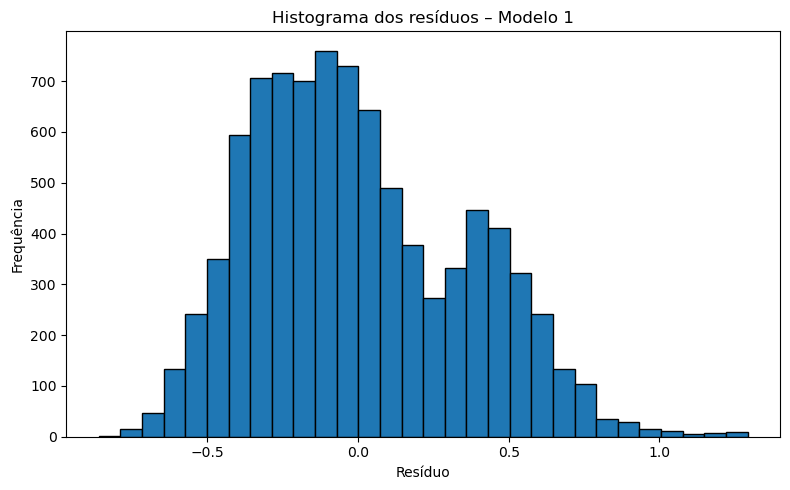

In [29]:
# Histograma dos residuos
plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=30, edgecolor="black")
plt.title("Histograma dos resíduos – Modelo 1")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

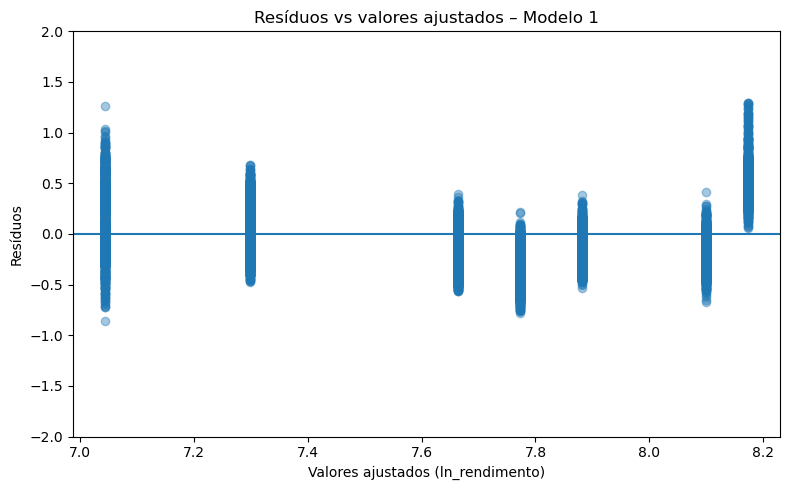

In [30]:
# Scatter: resíduos vs valores ajustados
plt.figure(figsize=(8, 5))
plt.scatter(ajustados, residuos, alpha=0.4)
plt.axhline(y=0)
plt.ylim(-2, 2)
plt.title("Resíduos vs valores ajustados – Modelo 1")
plt.xlabel("Valores ajustados (ln_rendimento)")
plt.ylabel("Resíduos")
plt.tight_layout()
plt.show()

<Figure size 600x600 with 0 Axes>

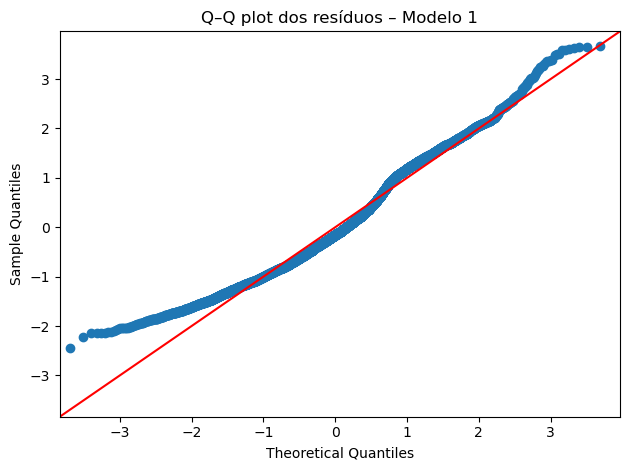

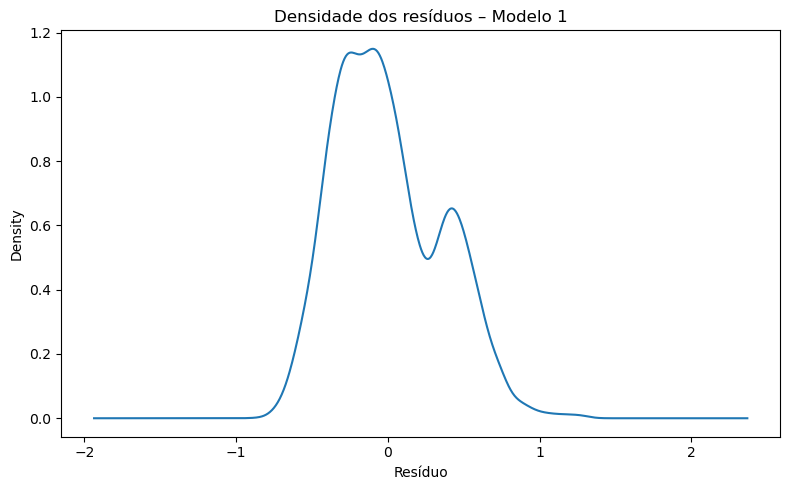

=== Teste de Breusch–Pagan (BP) ===
Estatística LM: 97.025
p-valor (LM):   0.0000
Estatística F:  98.074
p-valor (F):    0.0000

=== Teste de White ===
Estatística LM: 881.883
p-valor (LM):   0.0000
Estatística F:  489.377
p-valor (F):    0.0000

=== Durbin–Watson ===
DW: 0.311


In [31]:
# ============================
# 2. Q–Q plot dos resíduos
# ============================
plt.figure(figsize=(6, 6))
sm.qqplot(residuos, line="45", fit=True)
plt.title("Q–Q plot dos resíduos – Modelo 1")
plt.tight_layout()
plt.show()

# ============================
# 3. Densidade dos resíduos (KDE simples)
# ============================
plt.figure(figsize=(8, 5))
residuos.plot(kind="kde")
plt.title("Densidade dos resíduos – Modelo 1")
plt.xlabel("Resíduo")
plt.tight_layout()
plt.show()

# ============================
# 4. Teste de Breusch–Pagan (heterocedasticidade)
# ============================
bp_stat, bp_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(residuos, exog)

print("=== Teste de Breusch–Pagan (BP) ===")
print(f"Estatística LM: {bp_stat:.3f}")
print(f"p-valor (LM):   {bp_pvalue:.4f}")
print(f"Estatística F:  {bp_f:.3f}")
print(f"p-valor (F):    {bp_f_pvalue:.4f}")
print()

# ============================
# 5. Teste de White (heterocedasticidade geral)
# ============================
w_stat, w_pvalue, w_f, w_f_pvalue = het_white(residuos, exog)

print("=== Teste de White ===")
print(f"Estatística LM: {w_stat:.3f}")
print(f"p-valor (LM):   {w_pvalue:.4f}")
print(f"Estatística F:  {w_f:.3f}")
print(f"p-valor (F):    {w_f_pvalue:.4f}")
print()

# ============================
# 6. Durbin–Watson (autocorrelação dos resíduos)
# ============================
dw = sm.stats.stattools.durbin_watson(residuos)
print("=== Durbin–Watson ===")
print(f"DW: {dw:.3f}")

## Modelo 2: Pooled OLS

In [32]:
# Incluindo efeitos fixos de UF e tempo (ano + trimestre)

reg2 = smf.ols(
    "ln_rendimento ~ anos_estudo + C(uf) + C(ano) + C(trimestre)",
    data=df
).fit(cov_type="HC3")

print(reg2.summary())

                            OLS Regression Results                            
Dep. Variable:          ln_rendimento   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     553.7
Date:                Tue, 25 Nov 2025   Prob (F-statistic):               0.00
Time:                        00:23:38   Log-Likelihood:                -1542.9
No. Observations:                8883   AIC:                             3172.
Df Residuals:                    8840   BIC:                             3477.
Df Model:                          42                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

1. O que diz o modelo básico (sem controles)

Modelo:

ln(rendimento)=β0+β1anos_estudo+u

Principais resultados:

β1 = 0,0728 (p < 0,01)

R^2=0,537

Interpretação do coeficiente de anos de estudo

Como a variável dependente está em log, o coeficiente é uma aproximação da variação percentual do salário:

*  Cada ano adicional de estudo está associado a aprox. 7,3%–7,5% de aumento no rendimento médio.
*  Mais precisamente: 𝑒^0,0728−1≈7,5%

Intercepto (7,0079)

Representa o log do rendimento médio para alguém com 0 anos de estudo (na categoria base implícita).

Em termos de salário, isso daria algo em torno de e^7 ≈ mil e poucos reais — e é o **nível médio esperado de log-salário para indivíduos sem anos de estudo formais**, nas demais categorias de referência.

2. O que muda ao incluir UF, ano e trimestre

Modelo:


ln(rendimento)=β0+β1anos_estudo+γUF+δano+θtrim+u

Principais resultados:

β1 continua 0,0728, agora com z = 111,4 (super significativo);

R^2 aumenta de 0,537 para 0,692;

Entram 26 dummies de UF, 12 dummies de ano, 3 dummies de trimestre (UF base = Acre, ano base = 2012, trimestre base = 1).

Interpretação do retorno da educação

Ponto crucial:

Mesmo controlando pelas diferenças **estruturais entre estados e choques ao longo do tempo*, o retorno estimado da escolaridade**permanece praticamente idêntico (0,0728)**.

Isso sugere que a relação positiva entre anos de estudo e salários **não é apenas um artefato de morar em um estado mais rico ou em um ano específico, mas sim um padrão robusto**.

A inclusão de efeitos fixos por UF, ano e trimestre praticamente não altera o coeficiente associado à escolaridade, indicando que o retorno de aproximadamente 7,5% por ano adicional de estudo é robusto ao controle por heterogeneidade espacial e temporal.

Interpretação das UF (exemplos)

Lembrando: os coeficientes de C(uf) são diferenças em relação ao estado base (Acre).

Alguns exemplos bonitos para o texto:

São Paulo: coeficiente 0,3544
→ trabalhadores em SP têm, em média, algo como 40–45% de rendimento maior que no Acre, para mesmos anos de estudo e mesmo período.

Santa Catarina: coeficiente 0,3592
→ também na faixa de ~40–45% acima do Acre.

Distrito Federal: coeficiente 0,3782
→ diferença ainda maior, algo em torno de 45–50% a mais.

Maranhão: coeficiente -0,2627
→ salários cerca de 20–25% menores que no Acre, controlando por escolaridade e tempo.

Piauí: coeficiente -0,2682
→ muito parecido com o Maranhão, também bem abaixo do Acre.

Isso ilustra bem a desigualdade regional de salários, mesmo após controlar pela escolaridade.

Efeitos de ano e trimestre

Alguns anos mais recentes aparecem com coeficientes negativos (por exemplo, 2016, 2017, 2018, 2019, 2020), sugerindo que o log do rendimento médio nesses anos é inferior ao de 2012, mesmo controlando por escolaridade e UF.

As dummies de trimestre praticamente não têm efeito (coeficientes muito próximos de zero e não significativos), indicando que a variação sazonal trimestral no log-salário é pequena, dado o que já é capturado por ano + UF.


Interpretação da regressão básica

Inicialmente, estimou-se uma equação de Mincer simples, relacionando o logaritmo do rendimento mensal (ln_rendimento) aos anos de estudo. O coeficiente associado à variável anos_estudo foi de aproximadamente 0,073, estatisticamente significativo a 1%. Como a variável dependente está em logaritmo, esse resultado pode ser interpretado como um retorno médio da escolaridade em torno de 7,5% ao ano: cada ano adicional de estudo está associado a um aumento de cerca de 7,5% no rendimento, em média. O modelo apresenta um 𝑅^2 de 0,537, indicando que a escolaridade, sozinha, explica aproximadamente 54% da variação observada no logaritmo dos salários.

Interpretação com controles por UF e tempo

Em seguida, ampliou-se o modelo com a inclusão de dummies para Unidade da Federação (C(uf)), ano (C(ano)) e trimestre (C(trimestre)), de forma a controlar por heterogeneidade espacial e choques temporais comuns a todos os estados. Nessa especificação, o coeficiente de anos_estudo permaneceu praticamente inalterado (0,0728), altamente significativo, o que reforça a robustez do retorno estimado da educação: mesmo controlando por diferenças entre estados e por variações ao longo do tempo, um ano adicional de estudo continua associado a um aumento de aproximadamente 7,5% no rendimento médio. Além disso, o R^2 do modelo aumenta para 0,692, sugerindo que a inclusão dos efeitos fixos melhora substancialmente o poder explicativo da regressão.

Os coeficientes das dummies de UF evidenciam fortes disparidades regionais de rendimento. Tomando o Acre como categoria de referência, estados como São Paulo, Santa Catarina, Paraná, Distrito Federal e Mato Grosso apresentam prêmios salariais expressivos: por exemplo, o coeficiente de São Paulo (0,3544) indica que, para o mesmo nível de escolaridade e no mesmo período, os trabalhadores paulistas recebem em média algo entre 40% e 45% a mais do que trabalhadores do Acre. Em contraste, estados como Maranhão e Piauí exibem coeficientes negativos em torno de -0,26, o que sugere rendimentos entre 20% e 25% inferiores aos do estado de referência, mesmo após controlar pela escolaridade e pelo tempo.

Por fim, as dummies de ano capturam choques macroeconômicos ao longo do período analisado. Alguns anos recentes apresentam coeficientes negativos e estatisticamente significativos em relação a 2012, sugerindo redução no rendimento médio real dos trabalhadores, enquanto as dummies de trimestre não se mostram relevantes, indicando que a sazonalidade trimestral, uma vez controlados ano, UF e escolaridade, exerce papel limitado sobre os salários.

## Extensão: Níveis de Instrução
transformar em “prêmio por nível de instrução” estilo Mincer com dummies.

In [33]:
df["nivel_instrucao"].value_counts()

nivel_instrucao
Sem instrução e menos de 1 ano de estudo        1269
Ensino fundamental incompleto ou equivalente    1269
Ensino fundamental completo ou equivalente      1269
Ensino médio incompleto ou equivalente          1269
Ensino médio completo ou equivalente            1269
Ensino superior incompleto ou equivalente       1269
Ensino superior completo ou equivalente         1269
Name: count, dtype: int64

In [34]:
# Definir a categoria de referência
ref = "Sem instrução e menos de 1 ano de estudo"

In [35]:
# Rodar a regressão com dummies de nível de instrução
reg_niv = smf.ols(
    "ln_rendimento ~ C(nivel_instrucao, Treatment(reference=ref)) \
                     + C(uf) + C(ano) + C(trimestre)",
    data=df
).fit(cov_type="HC3")

print(reg_niv.summary())

                            OLS Regression Results                            
Dep. Variable:          ln_rendimento   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     2523.
Date:                Tue, 25 Nov 2025   Prob (F-statistic):               0.00
Time:                        00:24:02   Log-Likelihood:                 5773.1
No. Observations:                8883   AIC:                        -1.145e+04
Df Residuals:                    8835   BIC:                        -1.111e+04
Df Model:                          47                                         
Covariance Type:                  HC3                                         
                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

In [36]:
# Criar uma tabelinha com o “prêmio” em %
# filtrar só os coeficientes de nivel_instrucao
coef_niv = reg_niv.params.filter(like="C(nivel_instrucao")

tabela_niv = (
    pd.DataFrame({
        "nivel_instrucao": coef_niv.index,
        "beta": coef_niv.values
    })
)

In [37]:
# limpar o nome da coluna
tabela_niv["nivel_instrucao"] = (
    tabela_niv["nivel_instrucao"]
    .str.replace(r"C\(nivel_instrucao, Treatment\(reference=.*\)\)\[T\.", "", regex=True)
    .str.replace("]", "", regex=False)
)

In [38]:
# prêmio percentual em relação ao grupo base
tabela_niv["premio_%"] = (np.exp(tabela_niv["beta"]) - 1) * 100

tabela_niv.sort_values("premio_%", inplace=True)
tabela_niv

,nivel_instrucao,beta,premio_%
1,Ensino fundamental incompleto ou equivalente,0.177883,19.468612
3,Ensino médio incompleto ou equivalente,0.249908,28.390740
0,Ensino fundamental completo ou equivalente,0.323433,38.186406
2,Ensino médio completo ou equivalente,0.548444,73.055902
5,Ensino superior incompleto ou equivalente,0.728960,107.292308
4,Ensino superior completo ou equivalente,1.489981,343.701307


1. Leitura dos níveis de instrução (prêmio salarial)

A base de comparação é:
“Sem instrução e menos de 1 ano de estudo” (ref).

Fundamental incompleto

β ≈ 0,178 → prêmio ≈ 19,5%

Quem tem fundamental incompleto ganha, em média, cerca de 19% a mais do que alguém sem instrução, controlando por UF, ano e trimestre.

Fundamental completo

β ≈ 0,323 → prêmio ≈ 38,2%

Completar o fundamental praticamente dobra o ganho em relação ao fundamental incompleto (de 19% para 38% acima do grupo sem instrução).

Médio incompleto

β ≈ 0,250 → prêmio ≈ 28,4%

Já mostra um salto em relação ao grupo sem instrução, mas ainda abaixo do fundamental completo.

Médio completo

β ≈ 0,548 → prêmio ≈ 73,1%

Quem conclui o ensino médio ganha, em média, algo como 73% a mais do que indivíduos sem instrução.

Superior incompleto

β ≈ 0,729 → prêmio ≈ 107,3%

Ou seja, mais que o dobro do salário do grupo sem instrução.

Superior completo

β ≈ 1,490 → prêmio ≈ 343,7%

Isso quer dizer que, em média, quem tem ensino superior completo recebe um rendimento cerca de 3,4 vezes maior do que o grupo sem instrução, mantendo constantes UF, ano e trimestre.

Mensagem central: há uma escada bem nítida de retornos à educação: cada degrau educacional traz um prêmio positivo, e o salto mais expressivo é associado ao ensino superior completo.

2. Comparação com o modelo com anos de estudo contínuo

No modelo com anos de estudo contínuo, o retorno era de ~7,5% por ano, e o R^2 era 0,692 (com UF, ano e trimestre).

No modelo com dummies de nível de instrução, o R^2 sobe para 0,941, ou seja, a classificação em níveis (fundamental, médio, superior etc.) captura muito mais da variação do log-salário do que tratar a educação apenas como “número de anos”.

Como interpretar isso no texto:

A especificação com anos de estudo supõe um retorno linear: cada ano adicional vale a mesma coisa.

A especificação com níveis permite que certos “marcos” educacionais (como completar o médio ou o superior) gerem saltos discretos de renda, que é o que os seus resultados mostram claramente.

Em uma especificação alternativa, substituiu-se a medida contínua de escolaridade (anos de estudo) por dummies de nível de instrução, tomando como categoria de referência o grupo “Sem instrução e menos de 1 ano de estudo”. O objetivo foi identificar o prêmio salarial associado a cada degrau educacional, controlando por diferenças entre Unidades da Federação, ano e trimestre.

Os resultados indicam uma relação fortemente crescente entre nível de instrução e rendimentos. Em relação ao grupo sem instrução, indivíduos com ensino fundamental incompleto apresentam salários, em média, cerca de 19,5% maiores, enquanto aqueles com ensino fundamental completo ganham aproximadamente 38,2% a mais. No ensino médio, o prêmio aumenta de cerca de 28,4% para o grupo com médio incompleto para cerca de 73,1% para indivíduos com ensino médio completo.

Os maiores diferenciais aparecem nos níveis superiores. Trabalhadores com ensino superior incompleto auferem rendimentos em torno de 107,3% superiores aos do grupo sem instrução, e aqueles com ensino superior completo recebem, em média, aproximadamente 343,7% a mais, o que significa algo como 3,4 vezes o salário dos indivíduos sem escolaridade formal. Esses resultados sugerem que a conclusão de marcos educacionais – especialmente o ensino médio e, principalmente, o ensino superior – está associada a ganhos salariais substanciais.

Em termos de ajuste, o modelo com dummies de nível de instrução apresenta um R^2 de 0,941, bem superior ao observado no modelo com anos de estudo contínuos (cerca de 0,692). Isso indica que a diferenciação por níveis educacionais explica de forma mais precisa a variação dos salários do que a simples contagem de anos de estudo, sugerindo que o mercado de trabalho recompensa de maneira não linear a escolaridade, com prêmios elevados para a conclusão de certos ciclos educacionais.

## Modelo 3: Efeitos Fixos PanelOLS

In [39]:
# Modelo 3: Painel com FE “oficial” (linearmodels)
# criar um índice de tempo t = 0,1,2,... para cada ano-trimestre
df = df.copy()
df["t"] = (df["ano"] - df["ano"].min()) * 4 + (df["trimestre"] - 1)

# transformar em painel: MultiIndex [uf, t]
df_panel = df.set_index(["uf", "t"])

In [40]:
# Estimar o FE com efeitos de entidade (UF) e de tempo
fe_mod = PanelOLS.from_formula(
    "ln_rendimento ~ 1 + anos_estudo + EntityEffects + TimeEffects",
    data=df_panel
).fit(cov_type="robust")

print(fe_mod.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:          ln_rendimento   R-squared:                        0.6364
Estimator:                   PanelOLS   R-squared (Between):           -2.22e-16
No. Observations:                8883   R-squared (Within):               0.6331
Date:                Tue, Nov 25 2025   R-squared (Overall):              0.5375
Time:                        00:24:03   Log-likelihood                   -1537.2
Cov. Estimator:                Robust                                           
                                        F-statistic:                   1.542e+04
Entities:                          27   P-value                           0.0000
Avg Obs:                       329.00   Distribution:                  F(1,8809)
Min Obs:                       329.00                                           
Max Obs:                       329.00   F-statistic (robust):          1.245e+04
                            

Modelo 3 – Painel com efeitos fixos “oficial” (linearmodels)

Saída do PanelOLS:

Coeficiente de anos_estudo: 0,0728 (p < 0,01)

R^2 Within = 0,6331

R^2 Overall = 0,5375

F-test de poolability = 61,906, p-valor = 0,0000

→ rejeita fortemente a hipótese de que o modelo pooled é adequado.

Interpretação do coeficiente:

e^0,0728 − 1 ≈ 7,6%

Ou seja, mesmo com efeitos fixos por UF e por tempo, o retorno da escolaridade continua na casa de 7,5–7,6% ao ano.

No Modelo 3, estimou-se um modelo de efeitos fixos utilizando a classe PanelOLS do pacote linearmodels, com inclusão de efeitos fixos para as entidades (UF) e para os períodos de tempo. Essa abordagem controla explicitamente por características não observadas e invariantes no tempo em cada estado (por exemplo, estrutura produtiva, cultura local, instituições), além de efeitos comuns de cada período.

O coeficiente associado à variável anos_estudo permanece em 0,0728, altamente significativo, o que implica um retorno da escolaridade de aproximadamente 7,6% por ano adicional de estudo, muito próximo ao obtido no Modelo 2. O R^2 within é de 0,6331, indicando que, após eliminar as médias por UF, a variação intra-estado ao longo do tempo continua sendo bem explicada pela escolaridade. O teste de poolabilidade (F = 61,9; p < 0,001) rejeita a hipótese de que o modelo pooled seja adequado, reforçando a necessidade de utilizar um modelo com efeitos fixos. Em outras palavras, há evidências de que as diferenças não observadas entre estados estão correlacionadas com a escolaridade, o que torna o estimador de efeitos fixos mais apropriado do que o pooled OLS.

## Comparação dos 3 Modelos

In [41]:
# Comparação dos 3 Modelos
resumo = pd.DataFrame({
    "Modelo": ["(1) Cross-section", "(2) Pooled OLS", "(3) FE (PanelOLS)"],
    "Amostra": [
        "1º tri 2012 (UF)",
        "Painel UF × tempo",
        "Painel UF × tempo"
    ],
    "Método": [
        "OLS (HC3)",
        "Pooled OLS (HC3)",
        "Efeitos Fixos (Entity + Time, robust)"
    ],
    "Controles": [
        "Nenhum",
        "Dummies UF, ano, trimestre",
        "EF UF + EF tempo"
    ],
    "beta_anos_estudo": [0.0833, 0.0728, 0.0728],
    "retorno_%": [(np.exp(0.0833)-1)*100,
                  (np.exp(0.0728)-1)*100,
                  (np.exp(0.0728)-1)*100],
    "R2_principal": [0.614, 0.692, 0.633],   # FE: R² within
    "N": [189, 8883, 8883]
})

resumo

,Modelo,Amostra,Método,Controles,beta_anos_estudo,retorno_%,R2_principal,N
0,(1) Cross-section,1º tri 2012 (UF),OLS (HC3),Nenhum,0.0833,8.686782,0.614,189
1,(2) Pooled OLS,Painel UF × tempo,Pooled OLS (HC3),"Dummies UF, ano, trimestre",0.0728,7.551541,0.692,8883
2,(3) FE (PanelOLS),Painel UF × tempo,"Efeitos Fixos (Entity + Time, robust)",EF UF + EF tempo,0.0728,7.551541,0.633,8883


A Tabela resume os principais resultados das três especificações estimadas. Observa-se que o coeficiente associado aos anos de estudo permanece relativamente estável, entre 7,6% e 8,7% de retorno anual, mesmo com a introdução de controles regionais, temporais e de efeitos fixos. Isso reforça a robustez do efeito da escolaridade sobre os salários.

## Tabela-resumo dos prêmios por nível de instrução

In [42]:
# Tabela-resumo dos prêmios por nível de instrução
tabela_niveis = pd.DataFrame({
    "nivel_instrucao": [
        "Ensino fundamental incompleto ou equivalente",
        "Ensino fundamental completo ou equivalente",
        "Ensino médio incompleto ou equivalente",
        "Ensino médio completo ou equivalente",
        "Ensino superior incompleto ou equivalente",
        "Ensino superior completo ou equivalente",
    ],
    "beta": [
        0.177883,
        0.323433,
        0.249908,
        0.548444,
        0.728960,
        1.489981,
    ],
    "premio_%": [
        19.468612,
        38.186406,
        28.390740,
        73.055902,
        107.292308,
        343.701307,
    ]
})

tabela_niveis

,nivel_instrucao,beta,premio_%
0,Ensino fundamental incompleto ou equivalente,0.177883,19.468612
1,Ensino fundamental completo ou equivalente,0.323433,38.186406
2,Ensino médio incompleto ou equivalente,0.249908,28.390740
3,Ensino médio completo ou equivalente,0.548444,73.055902
4,Ensino superior incompleto ou equivalente,0.728960,107.292308
5,Ensino superior completo ou equivalente,1.489981,343.701307


A Tabela apresenta os prêmios salariais associados a cada nível de instrução, tomando como referência o grupo sem instrução. Observa-se uma clara progressão dos rendimentos à medida que aumenta a escolaridade. Indivíduos com ensino fundamental incompleto já apresentam salários cerca de 19,5% superiores aos do grupo de referência, enquanto aqueles com ensino fundamental completo ganham em torno de 38,2% a mais. No ensino médio, os prêmios aumentam para aproximadamente 28,4% (médio incompleto) e 73,1% (médio completo). Os maiores diferenciais aparecem nos níveis superiores: trabalhadores com ensino superior incompleto auferem rendimentos em torno de 107,3% superiores aos do grupo sem instrução, ao passo que indivíduos com ensino superior completo recebem, em média, cerca de 343,7% a mais, o que corresponde a mais de três vezes o salário do grupo de referência. Esses resultados evidenciam que o mercado de trabalho recompensa de forma não linear a escolaridade, com saltos expressivos de renda associados à conclusão do ensino médio e, sobretudo, do ensino superior.

## Conclusão geral

Os três modelos estimados neste trabalho apontam para um resultado extremamente consistente: **a escolaridade é um dos principais determinantes dos rendimentos do trabalho no Brasil**, com um retorno médio anual em torno de 7,6%.

No **Modelo 1**, foi estimada uma regressão minceriana básica do logaritmo do salário (`ln_rendimento`) em função dos anos de estudo (`anos_estudo`), utilizando toda a amostra (N = 8.883). O coeficiente estimado para `anos_estudo` foi de aproximadamente **0,0728**, o que implica um retorno de cerca de **7,6% de salário adicional por ano de estudo**. Mesmo sem quaisquer controles regionais ou temporais, o modelo apresenta um \(R^2 \approx 0{,}54\), indicando que a escolaridade, sozinha, explica mais da metade da variação observada no logaritmo do rendimento. Por outro lado, os diagnósticos de resíduos revelam heterocedasticidade e autocorrelação, reforçando que se trata de um modelo inicial, útil como referência, mas ainda simplificado frente à estrutura em painel dos dados.

O **Modelo 2** amplia a especificação ao incorporar dummies para **UF, ano e trimestre**, passando a considerar explicitamente diferenças regionais e temporais. Apesar da inclusão desses controles, o coeficiente de `anos_estudo` permanece praticamente inalterado (**0,0728**, retorno de ~7,6% ao ano), o que sugere que o efeito estimado da escolaridade não é fruto apenas de correlações espúrias com a localização geográfica ou com o ciclo macroeconômico. O \(R^2\) do modelo aumenta para cerca de **0,69**, evidenciando que uma parte relevante da variação salarial está associada a fatores regionais e de período, mas sem reduzir a importância da educação.

No **Modelo 3**, é estimado um painel com **efeitos fixos por UF e por tempo** (PanelOLS), que controla por heterogeneidade não observada constante no tempo em cada estado, além de efeitos comuns a todos os estados em cada período. Novamente, o coeficiente de `anos_estudo` permanece em torno de **0,0728**, confirmando um retorno médio de **7,6% ao ano**, agora com foco na variação **dentro de cada UF ao longo do tempo** (\(R^2\) within ≈ 0,63). O teste de poolabilidade rejeita a hipótese de que o modelo pooled seja suficiente, indicando que os efeitos fixos são relevantes; ainda assim, a estabilidade do coeficiente de escolaridade entre os modelos reforça a **robustez do resultado**.

A **extensão com dummies de nível de instrução** aprofunda a análise ao substituir `anos_estudo` por categorias educacionais (tendo como referência o grupo “sem instrução e menos de 1 ano de estudo”). Os resultados mostram prêmios salariais crescentes e fortemente não lineares: aproximadamente **+19,5%** para ensino fundamental incompleto, **+38,2%** para fundamental completo, **+73,1%** para médio completo, **+107,3%** para superior incompleto e cerca de **+343,7%** para superior completo. Ou seja, indivíduos com ensino superior completo recebem, em média, salários mais de **três vezes superiores** aos do grupo sem instrução, mesmo após controlar por UF, ano e trimestre. Isso indica que o mercado de trabalho não recompensa apenas anos adicionais de estudo de forma linear, mas especialmente a **conclusão de certos ciclos educacionais**, em particular ensino médio e ensino superior.

Em conjunto, os resultados dos três modelos principais e da extensão por níveis de instrução permitem concluir que:

- a escolaridade exerce um **efeito positivo, elevado e estatisticamente robusto** sobre os salários;
- diferenças regionais e temporais são importantes para explicar a dispersão salarial, mas **não eliminam** o impacto da educação;
- o retorno da escolaridade não é apenas linear: **certos diplomas** (médio e superior) estão associados a **saltos expressivos de rendimento**;
- a consistência dos coeficientes entre OLS simples, pooled com dummies e efeitos fixos sugere que estamos captando um **efeito estrutural** e não apenas correlações espúrias.

Do ponto de vista de políticas públicas, os achados reforçam a relevância de estratégias voltadas à **expansão do acesso à educação** e, sobretudo, ao **incentivo à conclusão de ciclos educacionais** (ensino médio e superior), como instrumentos de aumento de renda, mobilidade social e redução da desigualdade no Brasil.






